In [1]:
import pandas as pd

# LOAD THE DATA
url = "https://drive.google.com/uc?export=download&id=1p-bEuJkrmmpXtCviEE3YvBKrEW7b_K3y"

# read file
try:
    df = pd.read_excel(url, engine="openpyxl")
except:
    df = pd.read_csv(url)

# show top 10 rows
df.head(10)

,Make,Type,Year,Origin,Color,Options,Engine_Size,Fuel_Type,Gear_Type,Mileage,Region,Price,Negotiable
0,Chrysler,C300,2018,Saudi,Black,Full,5.7,Gas,Automatic,103000,Riyadh,114000,False
1,Nissan,Patrol,2016,Saudi,White,Full,4.8,Gas,Automatic,5448,Riyadh,0,True
2,Nissan,Sunny,2019,Saudi,Silver,Standard,1.5,Gas,Automatic,72418,Riyadh,27500,False
3,Hyundai,Elantra,2019,Saudi,Grey,Standard,1.6,Gas,Automatic,114154,Riyadh,43000,False
4,Hyundai,Elantra,2019,Saudi,Silver,Semi Full,2.0,Gas,Automatic,41912,Riyadh,59500,False
5,Honda,Accord,2018,Saudi,Navy,Full,1.5,Gas,Automatic,39000,Riyadh,72000,False
6,Toyota,Land Cruiser,2011,Saudi,White,Semi Full,4.5,Gas,Automatic,183000,Riyadh,92000,False
7,GMC,Yukon,2009,Saudi,Bronze,Full,5.7,Gas,Automatic,323000,Riyadh,0,True
8,Chevrolet,Impala,2019,Saudi,Black,Standard,3.6,Gas,Automatic,70000,Riyadh,80000,False
9,Toyota,Yaris,2018,Saudi,White,Standard,1.5,Gas,Automatic,131000,Jeddah,32000,False


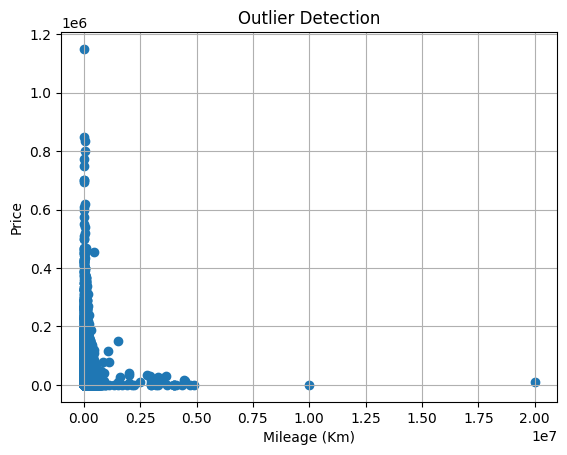

In [2]:
#OUTLIER DETECTION
#DATA UNDERSTANDING : FROM THIS ANALYSIS WE CAN CONCLUDE THE ANOMALIES OF THE DATA
 #FINDING 1 : UNIT WITH VERY HIGH KM (DIRECTLY CLEANSED)
 #FINDING 2 : UNIT WITH PRICE = 0 --> NOT DIRECTLI CLEANSED BUT ANALYZED SEPARATELY

import matplotlib.pyplot as plt
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

plt.scatter(df["Mileage"], df["Price"])

plt.xlabel("Mileage (Km)")
plt.ylabel("Price")
plt.title("Outlier Detection")

plt.grid(True)
plt.show()

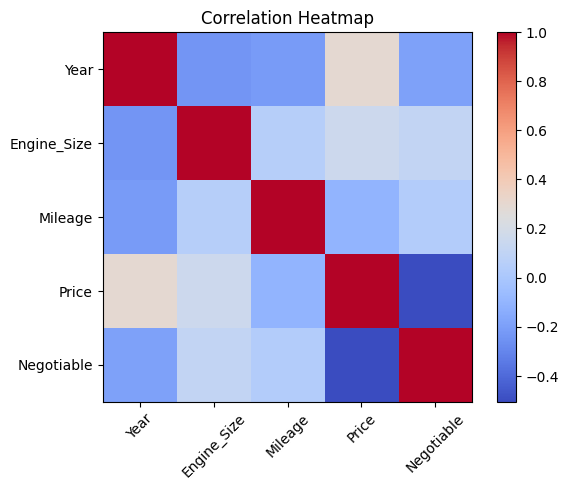

In [3]:
#CORRELATION HEATMAP
#DATA UNDERSTANDING : ANALYSIS TO FIND THE PARAMETER THAT MUST BE TREATED WITH UTMOST FOCUS
#FINDING : PRICE HAVE THE MOST POSITIVE CORRELATION

df = pd.read_csv(url)

# numeric conversion
for col in ["Mileage", "Price", "Year", "Engine"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# correlation matrix
corr = df.corr(numeric_only=True)

# plot
plt.imshow(corr, cmap="coolwarm")

plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

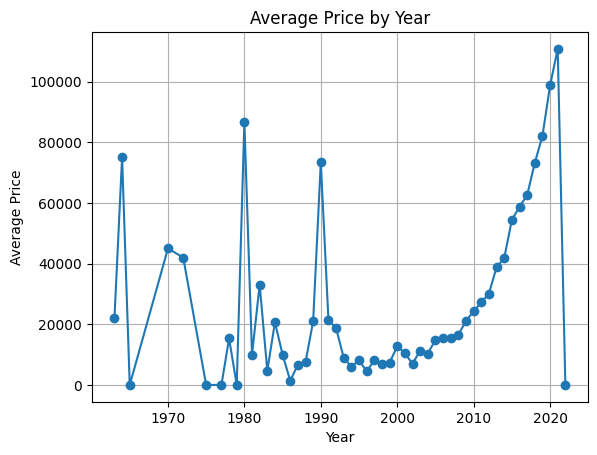

In [4]:
#YEAR VS PRICE CHART
#DATA UNDERSTANDING : WE TRY TO CONFIRM THE VALUE OF A UNIT BASED ON YEAR PRODUCTION
#INSIGHT : FROM THIS WE KNOW FOR SURE THE DATA IMPLIED YOUNGER UNIT HAVE MORE VALUE SO TO KNOW THE UNIT'S CONDITION WE CAN CONCLUDE FROM ON YEAR AND MILEAGE
 #FINDING 1 : THE PATTERN MIRRORED CHART PRICE VS MILEAGE, THIS MEAN MOST OF THE SAMPLED UNIT'S PRODUCTION YEAR NEGATIVELY CORRELATED WITH MILEAGE (BIGGER YEAR-->LESS KM)
 #FINDING 2 : THERES SPIKE ON PRICE FOR UNIT WITH OLDER YEAR, THIS MEAN THERE'S ANOTHER PRICE DRIVER OTHER THAN CONDITION OF THE UNIT

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

avg_price = df.groupby("Year")["Price"].mean()

avg_price.plot(marker="o")

plt.xlabel("Year")
plt.ylabel("Average Price")
plt.title("Average Price by Year")

plt.grid(True)
plt.show()

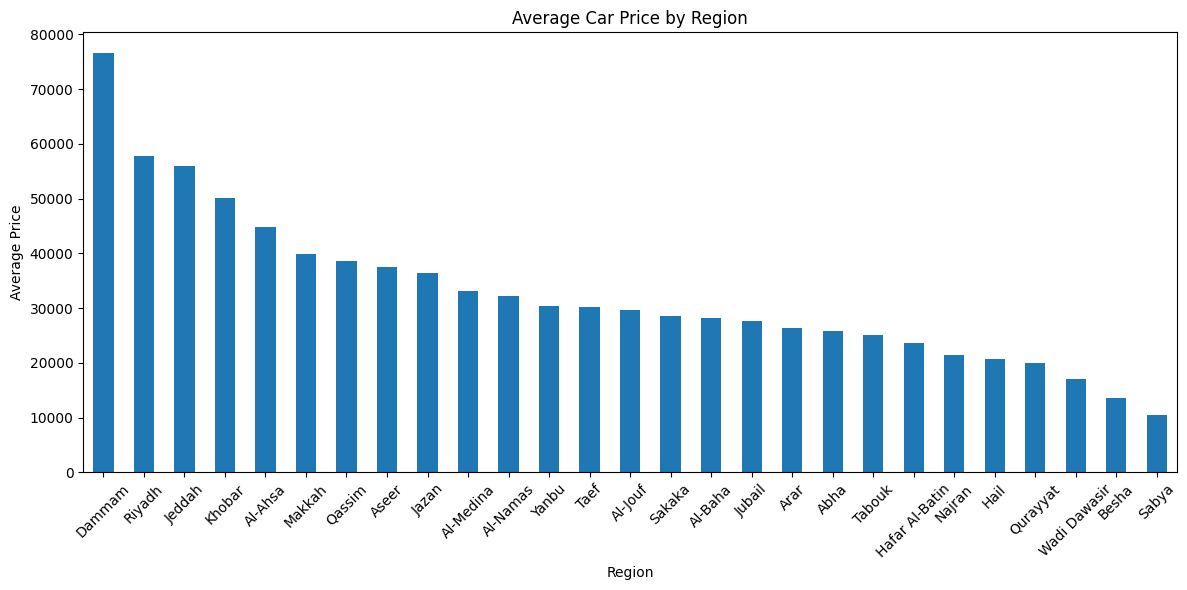

In [5]:
#PRICE VS REGION
#DATA UNDERSTANDING : FROM THIS WE KNEW THAT EVERY CITY VERY DIFFER IN PRICE
#FINDING : THERE'S A GAP FOR PRICE BETWEEN CITIES

# convert price to numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# remove missing values
df = df.dropna(subset=["Region", "Price"])

# calculate average price by city/region
avg_price = (
    df.groupby("Region")["Price"]
      .mean()
      .sort_values(ascending=False)
)

# bar chart
avg_price.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Car Price by Region")
plt.xlabel("Region")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

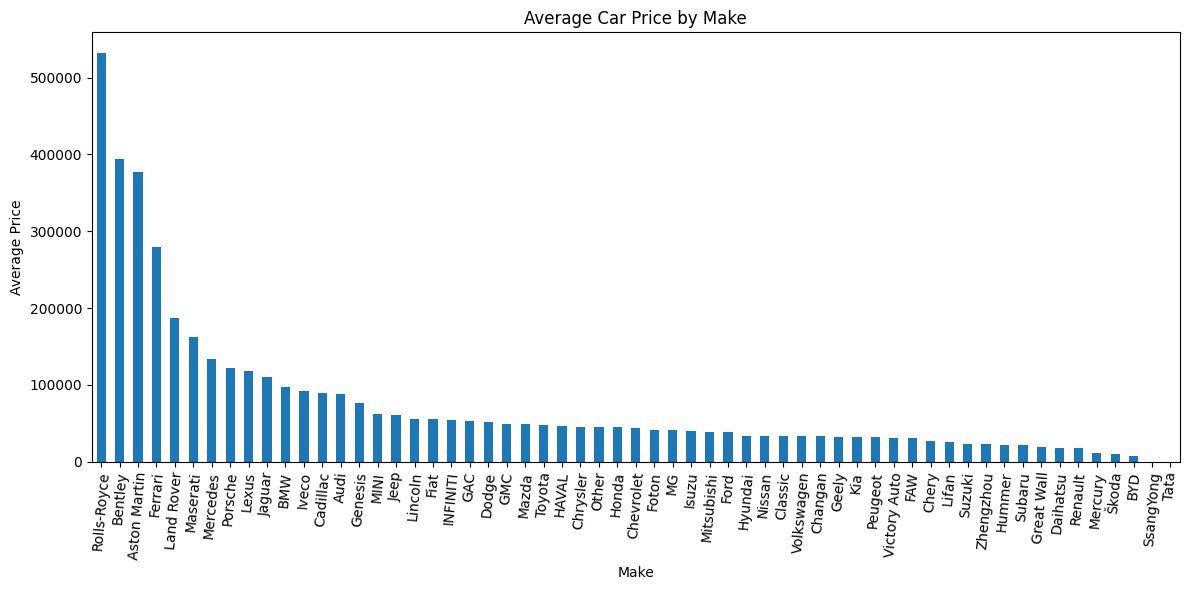

In [ ]:
#PRICE VS UNIT BRAND
#DATA UNDERSTANDING : FROM THIS WE CONFIRM THAT CERTAIN BRAND HAVE CERTAIN VALUE
#FINDING : THERE'S A GAP FOR PRICE BETWEEN UNIT'S BRAND, BUT THE GAP ISN'T AS OBVIOUS AS REGION VS PRICE

# load dataset
df = pd.read_csv(url)

# convert price to numeric
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# remove missing values
df = df.dropna(subset=["Make", "Price"])

# calculate average price by city/region
avg_price = (
    df.groupby("Make")["Price"]
      .mean()
      .sort_values(ascending=False)
)

# bar chart
avg_price.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Car Price by Make")
plt.xlabel("Make")
plt.ylabel("Average Price")
plt.xticks(rotation=85)
plt.tight_layout()

plt.show()


=== Average Price by Region ===
Region
Dammam            76529.375912
Riyadh            57724.677788
Jeddah            56009.611954
Khobar            50157.195652
Al-Ahsa           44806.757447
Makkah            39863.788546
Qassim            38569.466019
Aseer             37511.225108
Jazan             36371.255556
Al-Medina         33066.178451
Yanbu             30361.111111
Taef              30111.605839
Al-Jouf           29697.945946
Al-Baha           28187.500000
Jubail            27635.703297
Arar              26268.250000
Abha              25843.139535
Tabouk            25105.346154
Hafar Al-Batin    23550.863636
Najran            21495.684211
Hail              20687.105882
Name: Price, dtype: float64

=== ANOVA RESULTS ===
F-statistic : 17.3487
P-value     : 0.0000000000

Conclusion:
Average prices differ significantly between regions.


<Figure size 1400x600 with 0 Axes>

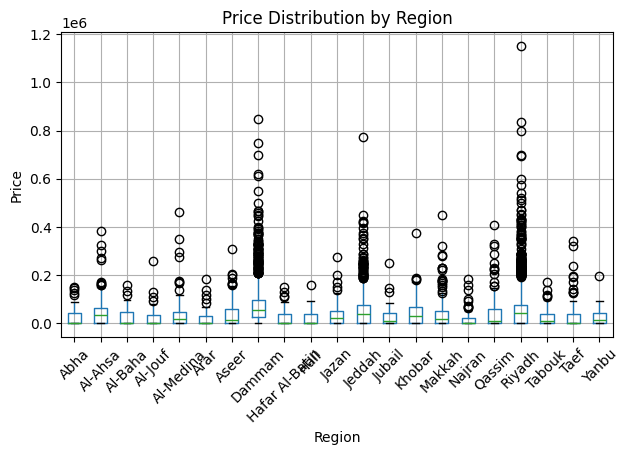

In [22]:
#INFERENCE STATISTIC AND MASS BOXPLOT
#DATA UNDERSTANDING : WITH THIS 2 METHOD WE KNEW BETTER THE PRICE VARIANCE EACH CITY AND HOW IT REACT VERY DIFFERENTLY ON EACH CITY
#INSIGHT : FROM ANOVA IT'S PROVEN THAT PRICES DIFFER SIGNIFICANTLY BETWEEN REGION
 #FINDING 1 : FROM BOXPLOT WE KNEW THERE ARE VARIANCES BETWEEN UNITS ON EACH REGION
 #FINDING 2 : THE BOXPLOT'S OUTLIER SAID THERE IS STILL A PARAMETER THAT BECOME THE MAIN PRICE DRIVER THAT WE SHOULD FIND

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import f_oneway



# Clean data
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df = df.dropna(subset=["Region", "Price"])

# Optional:
# Keep only regions with enough observations
MIN_LISTINGS = 30

region_counts = df["Region"].value_counts()
valid_regions = region_counts[region_counts >= MIN_LISTINGS].index

df = df[df["Region"].isin(valid_regions)]

# Average price by region
avg_price = (
    df.groupby("Region")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print("\n=== Average Price by Region ===")
print(avg_price)

# Prepare groups for ANOVA
groups = [
    group["Price"].values
    for _, group in df.groupby("Region")
]

# Run ANOVA
f_stat, p_value = f_oneway(*groups)

print("\n=== ANOVA RESULTS ===")
print(f"F-statistic : {f_stat:.4f}")
print(f"P-value     : {p_value:.10f}")

if p_value < 0.05:
    print("\nConclusion:")
    print("Average prices differ significantly between regions.")
else:
    print("\nConclusion:")
    print("No statistically significant difference in average prices between regions.")

# Visualization
plt.figure(figsize=(14,6))

df.boxplot(
    column="Price",
    by="Region",
    rot=45
)

plt.title("Price Distribution by Region")
plt.suptitle("")
plt.xlabel("Region")
plt.ylabel("Price")

plt.tight_layout()
plt.show()

In [7]:

#THE USE OFREGRESSION
#DATA UNDERSTANDING : FROM THIS WE TRY TO FIND WHAT PARAMETER IS THE PRICE DRIVER
#FINDING : DESPITE OUR CLEANSING, THE DATA IS TOO "NOISY" TO BE CONCLUDED

import statsmodels.formula.api as smf
df = pd.read_csv(url)

# ==========================================
# CLEAN DATA
# ==========================================

numeric_cols = [
    "Price",
    "Mileage",
    "Year",
    "Engine_Size"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

required_cols = [
    "Price",
    "Mileage",
    "Year",
    "Engine_Size",
    "Make",
    "Type",
    "Origin",
    "Color",
    "Fuel_Type",
    "Gear_Type",
    "Region"
]

df = df.dropna(subset=required_cols)

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(f"Rows used               : {len(df):,}")
print(f"Distinct Makes          : {df['Make'].nunique()}")
print(f"Distinct Types          : {df['Type'].nunique()}")
print(f"Distinct Regions        : {df['Region'].nunique()}")

print()

# ==========================================
# MULTIPLE REGRESSION
# ==========================================

formula = """
Price ~ Mileage
       + Year
       + Engine_Size
       + C(Make)
       + C(Type)
       + C(Origin)
       + C(Color)
       + C(Fuel_Type)
       + C(Gear_Type)
       + C(Region)
"""

model = smf.ols(
    formula=formula,
    data=df
).fit()

# ==========================================
# MODEL PERFORMANCE
# ==========================================

print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"R-squared      : {model.rsquared:.4f}")
print(f"Adjusted R²    : {model.rsquared_adj:.4f}")

print()

# ==========================================
# FULL REGRESSION SUMMARY
# ==========================================

print("=" * 70)
print("FULL REGRESSION SUMMARY")
print("=" * 70)

print(model.summary())

# ==========================================
# COEFFICIENT TABLE
# ==========================================

coef_table = pd.DataFrame({
    "Coefficient": model.params,
    "P_Value": model.pvalues
})

coef_table["Abs_Coefficient"] = (
    coef_table["Coefficient"]
    .abs()
)

coef_table = coef_table.sort_values(
    by="P_Value"
)

print()
print("=" * 70)
print("COEFFICIENT TABLE")
print("=" * 70)

print(
    coef_table[
        ["Coefficient", "P_Value"]
    ].round(4)
)

# ==========================================
# SIGNIFICANT VARIABLES
# ==========================================

significant = coef_table[
    coef_table["P_Value"] < 0.05
]

print()
print("=" * 70)
print("STATISTICALLY SIGNIFICANT VARIABLES")
print("=" * 70)

print(
    significant[
        ["Coefficient", "P_Value"]
    ].round(4)
)

# ==========================================
# TOP POSITIVE PRICE DRIVERS
# ==========================================

positive = coef_table[
    coef_table["Coefficient"] > 0
].sort_values(
    by="Coefficient",
    ascending=False
)

print()
print("=" * 70)
print("TOP POSITIVE PRICE DRIVERS")
print("=" * 70)

print(
    positive.head(20)[
        ["Coefficient", "P_Value"]
    ].round(4)
)

# ==========================================
# TOP NEGATIVE PRICE DRIVERS
# ==========================================

negative = coef_table[
    coef_table["Coefficient"] < 0
].sort_values(
    by="Coefficient"
)

print()
print("=" * 70)
print("TOP NEGATIVE PRICE DRIVERS")
print("=" * 70)

print(
    negative.head(20)[
        ["Coefficient", "P_Value"]
    ].round(4)
)

# ==========================================
# INVESTOR SUMMARY
# ==========================================

print()
print("=" * 70)
print("INVESTOR SUMMARY")
print("=" * 70)

print(
    f"The regression model explains "
    f"{model.rsquared_adj * 100:.1f}% "
    f"of vehicle price variation "
    f"(Adjusted R²)."
)

print()

print(
    "Variables with p-value < 0.05 are statistically "
    "significant drivers of vehicle price."
)

print()

print(
    "Review the Positive and Negative Price Drivers "
    "sections to identify the strongest pricing factors."
)

DATASET OVERVIEW
Rows used               : 8,035
Distinct Makes          : 59
Distinct Types          : 381
Distinct Regions        : 27

MODEL PERFORMANCE
R-squared      : 0.4716
Adjusted R²    : 0.4404

FULL REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     15.11
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:30:38   Log-Likelihood:                -98703.
No. Observations:                8035   AIC:                         1.983e+05
Df Residuals:                    7586   BIC:                         2.014e+05
Df Model:                         448                                         
Covariance Type:            nonrobust                       

In [8]:
#DATA UNDERSTANDING : R2 VALUE OF 0.4 IS STILL INCONCLUSIVE, NEED BETTER APPROACH TO GET BETTER R2 VALUE
#FINDING : BY GROUPING THE DATAFRAME OF COLUMN "NEGOTIABLE" WE ABLE TO MAKE CONFIRMATION OF THE 0 VALUES
#INSIGHT : WE MUST TRY TO CLEANSE OUR DATA FROM COLUMN "NEGOTIABLE" IN HOPE TO CLEAR THE NOISE AND RE RUN THE REGRESSION


df = pd.read_csv(url)

print(df.groupby("Negotiable")["Price"].agg(
    Count="count",
    Min="min",
    Max="max",
    Mean="mean"
))

            Count  Min      Max          Mean
Negotiable                                   
False        5509    0  1150000  78322.414413
True         2526    0        0      0.000000


In [9]:
#DATA UNDERSTANDING : THIS IS THE MODIFIED REGRESSION SCRIPT
#FINDING : THE DATA IS GIVING US FAR BETTER OUTCOME (R2=0.7)
#INSIGHT : TURN OUT THE "NEGOTIABLE" COLUMN GIVE NOISE TO THE DATA

import pandas as pd
import statsmodels.formula.api as smf

# ==========================================
# LOAD DATA
# ==========================================

url = "https://drive.google.com/uc?id=1p-bEuJkrmmpXtCviEE3YvBKrEW7b_K3y"

df = pd.read_csv(url)

# ==========================================
# CLEAN DATA
# ==========================================

numeric_cols = [
    "Price",
    "Mileage",
    "Year",
    "Engine_Size"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================================
# DATA QUALITY CHECK
# ==========================================

total_rows = len(df)

zero_price_rows = (df["Price"] == 0).sum()

print("=" * 70)
print("DATA QUALITY REPORT")
print("=" * 70)

print(f"Total listings              : {total_rows:,}")
print(f"Listings with Price = 0     : {zero_price_rows:,}")
print(f"Percentage removed          : {100 * zero_price_rows / total_rows:.2f}%")

# ==========================================
# REMOVE PRICE = 0
# ==========================================

df = df[df["Price"] > 0].copy()

remaining_rows = len(df)

print(f"Listings used in regression : {remaining_rows:,}")

# ==========================================
# REQUIRED COLUMNS
# ==========================================

required_cols = [
    "Price",
    "Mileage",
    "Year",
    "Engine_Size",
    "Make",
    "Type",
    "Origin",
    "Color",
    "Fuel_Type",
    "Gear_Type",
    "Region"
]

df = df.dropna(subset=required_cols)

print(f"Listings after NA removal   : {len(df):,}")

# ==========================================
# REGRESSION MODEL
# ==========================================

formula = """
Price ~ Mileage
       + Year
       + Engine_Size
       + C(Make)
       + C(Type)
       + C(Origin)
       + C(Color)
       + C(Fuel_Type)
       + C(Gear_Type)
       + C(Region)
"""

model = smf.ols(
    formula=formula,
    data=df
).fit()

# ==========================================
# MODEL PERFORMANCE
# ==========================================

print()
print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"R-squared      : {model.rsquared:.4f}")
print(f"Adjusted R²    : {model.rsquared_adj:.4f}")

# ==========================================
# FULL REGRESSION SUMMARY
# ==========================================

print()
print("=" * 70)
print("FULL REGRESSION SUMMARY")
print("=" * 70)

print(model.summary())

# ==========================================
# SIGNIFICANT VARIABLES
# ==========================================

coef_table = pd.DataFrame({
    "Coefficient": model.params,
    "P_Value": model.pvalues
})

significant = (
    coef_table[coef_table["P_Value"] < 0.05]
    .sort_values("P_Value")
)

print()
print("=" * 70)
print("STATISTICALLY SIGNIFICANT VARIABLES")
print("=" * 70)

print(significant.round(4))

# ==========================================
# TOP POSITIVE DRIVERS
# ==========================================

positive = (
    coef_table[coef_table["Coefficient"] > 0]
    .sort_values("Coefficient", ascending=False)
)

print()
print("=" * 70)
print("TOP POSITIVE PRICE DRIVERS")
print("=" * 70)

print(positive.head(20).round(4))

# ==========================================
# TOP NEGATIVE DRIVERS
# ==========================================

negative = (
    coef_table[coef_table["Coefficient"] < 0]
    .sort_values("Coefficient")
)

print()
print("=" * 70)
print("TOP NEGATIVE PRICE DRIVERS")
print("=" * 70)

print(negative.head(20).round(4))

# ==========================================
# INVESTOR STATEMENT
# ==========================================

print()
print("=" * 70)
print("INVESTOR STATEMENT")
print("=" * 70)

print(
    f"{zero_price_rows:,} listings "
    f"({100 * zero_price_rows / total_rows:.2f}% of the dataset) "
    f"were excluded because Price = 0."
)

print()

print(
    "These records represent undisclosed prices rather than "
    "actual vehicle values and would otherwise bias the regression."
)

print()

print(
    f"After removal, the model explains "
    f"{model.rsquared_adj * 100:.1f}% of observed vehicle price variation "
    f"(Adjusted R²)."
)

print()

print(
    "Variables with p-value < 0.05 are statistically significant "
    "drivers of vehicle price."
)

DATA QUALITY REPORT
Total listings              : 8,035
Listings with Price = 0     : 2,527
Percentage removed          : 31.45%
Listings used in regression : 5,508
Listings after NA removal   : 5,508

MODEL PERFORMANCE
R-squared      : 0.7373
Adjusted R²    : 0.7159

FULL REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     34.53
Date:                Thu, 04 Jun 2026   Prob (F-statistic):               0.00
Time:                        12:33:52   Log-Likelihood:                -65964.
No. Observations:                5508   AIC:                         1.328e+05
Df Residuals:                    5093   BIC:                         1.355e+05
Df Model:                         414                                      

In [12]:
#DATA UNDERSTANDING : WITH R2 VALUE OF 0.7 ONLY THEN WE CAN FIND WHICH PARAMETER IS THE PRICE DRIVER
#FINDING : COLUMN "TYPE" (THAT ALWAYS CORRELATED WITH COLUMN "TYPE") GIVE THE MOST R2 VALUE
#INSIGHT : WE FIND OUR MAIN PRICE DRIVER WHICH IS "TYPE" AND "MAKE"

import pandas as pd
import statsmodels.formula.api as smf

# ==========================================
# LOAD DATA
# ==========================================

url = "https://drive.google.com/uc?id=1p-bEuJkrmmpXtCviEE3YvBKrEW7b_K3y"

df = pd.read_csv(url)

# ==========================================
# CLEAN DATA
# ==========================================

df = df[df["Price"] > 0].copy()

numeric_cols = [
    "Price",
    "Mileage",
    "Year",
    "Engine_Size"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================================
# VARIABLES TO TEST
# ==========================================

variables = {
    "Make": "C(Make)",
    "Type": "C(Type)",
    "Year": "Year",
    "Origin": "C(Origin)",
    "Color": "C(Color)",
    "Engine_Size": "Engine_Size",
    "Fuel_Type": "C(Fuel_Type)",
    "Gear_Type": "C(Gear_Type)",
    "Mileage": "Mileage",
    "Region": "C(Region)"
}

results = []

# ==========================================
# RUN INDIVIDUAL REGRESSIONS
# ==========================================

for name, formula_part in variables.items():

    try:
        formula = f"Price ~ {formula_part}"

        model = smf.ols(
            formula=formula,
            data=df
        ).fit()

        results.append({
            "Variable": name,
            "R2": model.rsquared,
            "Adjusted_R2": model.rsquared_adj
        })

    except Exception as e:
        print(f"Error on {name}: {e}")

# ==========================================
# RESULTS TABLE
# ==========================================

r2_table = pd.DataFrame(results)

r2_table = r2_table.sort_values(
    by="Adjusted_R2",
    ascending=False
)

print("\nR² CONTRIBUTION BY VARIABLE\n")

print(r2_table.round(4))


R² CONTRIBUTION BY VARIABLE

      Variable      R2  Adjusted_R2
1         Type  0.5686       0.5392
0         Make  0.3603       0.3537
2         Year  0.0949       0.0947
5  Engine_Size  0.0923       0.0921
3       Origin  0.0316       0.0311
4        Color  0.0264       0.0239
9       Region  0.0231       0.0185
7    Gear_Type  0.0147       0.0145
8      Mileage  0.0142       0.0140
6    Fuel_Type  0.0022       0.0018


In [11]:
#DATA UNDERSTANDING 1 : WE EXPAND THE RECENT INSIGHT TO THE INSIGHT BEFORE (PRICE VARIANCE ON EACH "REGION")
#DATA UNDERSTANDING 2 : THEN WE MAKE A MERGED ANALYSIS AS AN APPROCH TO MAKE PRICE SEGMENTATION ON EACH REGION
#DATA UNDERSTANDING 3 : WE TRY TO GROUP TOP 5 MOST EXPENSIVE AND TOP 5 CHEAPEST UNIT TO TOP 5 CAR AVAILABLE ON EACH REGION
#DATA UNDERSTANDING 4 : WE ALSO GROUP IT TO DISTINCT COUNT OF CAR BRAND ON AND TOTAL LISTING ON EACH REGION TO MAKE OUR ANALYSIS MORE GRANULAR
#FINDING : THERE IS SOME MATCH ON THE CRITERIA
#INSIGHT1 : THE MATCHES ON MOST EXPENSIVE<->MOST AVAILABLE CAN BE TREATED AS HIGH SEGMENT (HIGHLIGHTED YELLOW ON THE DATA OUTPUT)
#INSIGHT2 : THE MATCHES ON CHEAPEST<->MOST AVAILABLE CAN BE TREATED AS LOW SEGMENT (UNDERLINED ON THE DATA OUTPUT)
#INSIGHT3 : IGNORE THE UNDERLINED AND HIGHLIGHTED YELLOW ON THE DATA OUTPUT AS IT'S BECAME BIAS ON CITY WITH LOW DISTINCT COUNT OF CAR BRAND AND AVAILABLE LISTING

## BUSINESS UNDERSTANDING ##
### PUSH THIS BRAND ON HIGH SEGMENT ON CORRESPONDING REGION : ###
#### HIGH SEGMENT ####
#### Jeddah : LEXUS
#### Taef : LEXUS
#### Jazan : TOYOTA
#### Abha : CHEVROLET
#### Hail : CHEVROLET
#### Hafar al Batin : TOYOTA
#### Al Namas : JEEP, TOYOTA
#### Al Jouf : CHEVROLET
#### Yanbu : DODGE
#### Najran : TOYOTA, GMC, FORD
#### Besha : CHEVROLET, HYUNDAI
#### Al Baha : CHEVROLET, MG, GMC
#### Arar : NISSAN, CHEVROLET, TOYOTA

#### LOW SEGMENT ####
#### Tabouk : FORD
#### Khobar : FORD
#### Arar : KIA
#### Najran : HYUNDAI, CHEVROLET
#### Al-Jouf : HYUNDAI, FORD
#### Yanbu : TOYOTA, MERCEDES
#### Besha : TOYOTA, NISSAN, LEXUS
#### Al Namas : NISSAN, FORD, MERCEDES
#### Qurayyat : NISSAN
#### Sakaka : NISSAN

from IPython.display import display, HTML

# Load dataset
df = pd.read_csv(url)

# Clean data
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df = df.dropna(subset=["Region", "Make", "Price"])

rows = []

for region in sorted(df["Region"].unique()):

    region_df = df[df["Region"] == region]

    # Skip empty regions
    if len(region_df) == 0:
        continue

    # Average price by make
    avg_price_by_make = (
        region_df
        .groupby("Make")["Price"]
        .mean()
        .sort_values(ascending=False)
    )

    # Top 3 most expensive makes
    top_expensive = (
        avg_price_by_make
        .head(5)
        .index
        .tolist()
    )

    # Top 3 cheapest makes
    top_cheapest = (
        avg_price_by_make
        .sort_values(ascending=True)
        .head(5)
        .index
        .tolist()
    )

    # Top 3 most available makes
    top_available = (
        region_df["Make"]
        .value_counts()
        .head(5)
        .index
        .tolist()
    )

    # Relationships
    expensive_available = (
        set(top_expensive) &
        set(top_available)
    )

    cheap_available = (
        set(top_cheapest) &
        set(top_available)
    )

    def format_make(make):

        styles = []

        # Highlight:
        # Most Expensive ∩ Most Available
        if make in expensive_available:
            styles.append(
                "background-color:yellow;"
            )
            styles.append(
                "font-weight:bold;"
            )
            styles.append(
                "padding:2px 4px;"
            )

        # Underline:
        # Most Cheap ∩ Most Available
        if make in cheap_available:
            styles.append(
                "text-decoration:underline;"
            )
            styles.append(
                "text-decoration-thickness:2px;"
            )

        if styles:
            return (
                f'<span style="{"".join(styles)}">'
                f'{make}'
                f'</span>'
            )

        return make

    expensive_html = ", ".join(
        format_make(make)
        for make in top_expensive
    )

    available_html = ", ".join(
        format_make(make)
        for make in top_available
    )

    cheapest_html = ", ".join(
        format_make(make)
        for make in top_cheapest
    )

    # Additional insights
    distinct_makes = (
        region_df["Make"]
        .nunique()
    )

    total_listings = len(region_df)

    rows.append({
        "Region": region,
        "Most Expensive": expensive_html,
        "Most Available": available_html,
        "Most Cheap": cheapest_html,
        "Distinct Makes": distinct_makes,
        "Total Listings": total_listings
    })

# Create result table
result = pd.DataFrame(rows)

# Optional:
# Sort by total listings descending
result = result.sort_values(
    "Total Listings",
    ascending=False
)

# Display HTML table
display(
    HTML(
        result.to_html(
            escape=False,
            index=False
        )
    )
)

Region,Most Expensive,Most Available,Most Cheap,Distinct Makes,Total Listings
Riyadh,"Rolls-Royce, Land Rover, Mercedes, Lexus, BMW","Toyota, Hyundai, Ford, Chevrolet, Nissan","SsangYong, Maserati, FAW, Other, Mercury",49,3237
Dammam,"Rolls-Royce, Bentley, Aston Martin, Ferrari, Maserati","Toyota, Ford, Hyundai, Chevrolet, Mercedes","Great Wall, Peugeot, Renault, Subaru, Mercury",45,1370
Jeddah,"Bentley, Cadillac, Jaguar, Lexus, Land Rover","Toyota, Hyundai, Ford, Nissan, Lexus","Tata, BYD, Isuzu, Great Wall, Mercury",46,1054
Qassim,"Land Rover, Other, BMW, Genesis, Isuzu","Toyota, Nissan, Hyundai, Ford, Chevrolet","Great Wall, Jeep, Mercury, Renault, Suzuki",29,309
Al-Medina,"Land Rover, Porsche, Great Wall, Mercedes, BMW","Toyota, Ford, Hyundai, Mazda, Nissan","Isuzu, Volkswagen, Genesis, Chrysler, Hummer",30,297
Al-Ahsa,"BMW, Land Rover, Lexus, Mercedes, Chrysler","Toyota, Ford, Chevrolet, Hyundai, Kia","Genesis, Suzuki, INFINITI, Daihatsu, MG",31,235
Aseer,"Jeep, MG, Jaguar, Lexus, Mercedes","Toyota, Hyundai, Ford, GMC, Chevrolet","Renault, BYD, Mazda, Kia, Chrysler",23,231
Makkah,"Bentley, Audi, Land Rover, BMW, Dodge","Toyota, Chevrolet, Hyundai, Ford, Nissan","Suzuki, Renault, Changan, BYD, Daihatsu",32,227
Taef,"Lexus, Dodge, Mercedes, Mazda, Honda","Toyota, GMC, Lexus, Ford, Chevrolet","Great Wall, Land Rover, Other, Lincoln, Chrysler",22,137
Tabouk,"Jeep, Genesis, Mazda, Dodge, Honda","Toyota, Hyundai, Chevrolet, Ford, Nissan","Geely, Isuzu, Mercedes, Peugeot, Ford",19,130


In [14]:
#DATA UNDERSTANDING 1 : WE THEN ANALYZE COLUMN "NEGOTIABLE" WITH DIFFERENT APPROACH
#DATA UNDERSTANDING 2 : WE RUN INFERENCE STATISTIC (CHI SQUARE TEST) TO FIND WHAT PARAMETER CAN BE ANALYZED CORRELATIVELY TO "NEGOTIABLE"
#FINDING :  SIGNIFICANT relationship, Negotiable status depends on Region

import pandas as pd
import scipy.stats as stats

# ==========================================
# LOAD DATA
# ==========================================

url = "https://drive.google.com/uc?id=1p-bEuJkrmmpXtCviEE3YvBKrEW7b_K3y"
df = pd.read_csv(url)

# ==========================================
# CLEAN DATA
# ==========================================

# Ensure correct types
df["Negotiable"] = df["Negotiable"].astype(str)

# We already know:
# Negotiable=True means Price=0 listings
# We'll still include all data for categorical test

# ==========================================
# CREATE CONTINGENCY TABLE
# ==========================================

table = pd.crosstab(df["Region"], df["Negotiable"])

print("\nCONTINGENCY TABLE (Region vs Negotiable)\n")
print(table)

# ==========================================
# CHI-SQUARE TEST
# ==========================================

chi2, p, dof, expected = stats.chi2_contingency(table)

print("\n==============================")
print("CHI-SQUARE TEST RESULT")
print("==============================")

print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p:.8f}")

# ==========================================
# INTERPRETATION
# ==========================================

print("\n==============================")
print("INTERPRETATION")
print("==============================")

if p < 0.05:
    print("Result: SIGNIFICANT relationship")
    print("Negotiable status depends on Region")
else:
    print("Result: NOT significant")
    print("Negotiable status is independent of Region")


CONTINGENCY TABLE (Region vs Negotiable)

Negotiable      False  True
Region                     
Abha               40    46
Al-Ahsa           158    77
Al-Baha            24    24
Al-Jouf            18    19
Al-Medina         172   125
Al-Namas           12     5
Arar               13    19
Aseer             130   101
Besha               6    17
Dammam           1119   251
Hafar Al-Batin     28    38
Hail               33    52
Jazan              54    36
Jeddah            783   271
Jubail             54    37
Khobar             63    29
Makkah            135    92
Najran             23    34
Qassim            161   148
Qurayyat            5     9
Riyadh           2308   929
Sabya               2     3
Sakaka              5     7
Tabouk             69    61
Taef               68    69
Wadi Dawasir        5    12
Yanbu              21    15

CHI-SQUARE TEST RESULT
Chi-square statistic : 428.4234
Degrees of freedom   : 26
P-value              : 0.00000000

INTERPRETATION
Result: SIGNI

In [15]:
#DATA UNDERSTANDING 1 : WE THEN ANALYZE COLUMN "NEGOTIABLE" WITH DIFFERENT APPROACH
#DATA UNDERSTANDING 2 : WE RUN INFERENCE STATISTIC (CHI SQUARE TEST) TO FIND WHAT PARAMETER CAN BE ANALYZED CORRELATIVELY TO "NEGOTIABLE"
#FINDING :  SIGNIFICANT relationship, Negotiable status depends on MAKE (BRAND)

import pandas as pd
import scipy.stats as stats

# ==========================================
# LOAD DATA
# ==========================================

url = "https://drive.google.com/uc?id=1p-bEuJkrmmpXtCviEE3YvBKrEW7b_K3y"
df = pd.read_csv(url)

# ==========================================
# CLEAN DATA
# ==========================================

df["Negotiable"] = df["Negotiable"].astype(str)

# Optional: limit very rare brands (helps stability)
# Keep top 20 makes only for cleaner inference
top_makes = df["Make"].value_counts().head(20).index
df_filtered = df[df["Make"].isin(top_makes)].copy()

# ==========================================
# CONTINGENCY TABLE
# ==========================================

table = pd.crosstab(df_filtered["Make"], df_filtered["Negotiable"])

print("\nCONTINGENCY TABLE (Make vs Negotiable)\n")
print(table)

# ==========================================
# CHI-SQUARE TEST
# ==========================================

chi2, p, dof, expected = stats.chi2_contingency(table)

print("\n==============================")
print("CHI-SQUARE TEST RESULT")
print("==============================")

print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p:.8f}")

# ==========================================
# INTERPRETATION
# ==========================================

print("\n==============================")
print("INTERPRETATION")
print("==============================")

if p < 0.05:
    print("Result: SIGNIFICANT relationship")
    print("Negotiable status depends on Make (brand)")
else:
    print("Result: NOT significant")
    print("Negotiable status is independent of Make")


CONTINGENCY TABLE (Make vs Negotiable)

Negotiable  False  True
Make                   
BMW            92    40
Changan        37    17
Chevrolet     423   221
Chrysler       47    24
Dodge          86    35
Ford          512   251
GMC           246   154
Genesis        46     9
Honda         138    45
Hyundai       719   222
Jeep           57    20
Kia           268    89
Land Rover     75    23
Lexus         237   106
Mazda         139    45
Mercedes      256    72
Mitsubishi     95    30
Nissan        362   186
Renault        37    18
Toyota       1263   775

CHI-SQUARE TEST RESULT
Chi-square statistic : 123.7782
Degrees of freedom   : 19
P-value              : 0.00000000

INTERPRETATION
Result: SIGNIFICANT relationship
Negotiable status depends on Make (brand)


In [16]:
#DATA UNDERSTANDING 1 : WE THEN ANALYZE COLUMN "NEGOTIABLE" WITH DIFFERENT APPROACH
#DATA UNDERSTANDING 2 : WE RUN INFERENCE STATISTIC (CHI SQUARE TEST) TO FIND WHAT PARAMETER CAN BE ANALYZED CORRELATIVELY TO "NEGOTIABLE"
#FINDING :  SIGNIFICANT relationship, Negotiable status depends on MILEAGE GROUP

import pandas as pd
import numpy as np
import scipy.stats as stats

# ==========================================
# LOAD DATA
# ==========================================

url = "https://drive.google.com/uc?id=1p-bEuJkrmmpXtCviEE3YvBKrEW7b_K3y"
df = pd.read_csv(url)

# ==========================================
# CLEAN DATA
# ==========================================

df["Negotiable"] = df["Negotiable"].astype(str)
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")

df = df.dropna(subset=["Mileage", "Negotiable"])

# ==========================================
# CREATE MILEAGE BINS
# ==========================================

df["Mileage_Group"] = pd.cut(
    df["Mileage"],
    bins=[0, 50000, 100000, 200000, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

# ==========================================
# CONTINGENCY TABLE
# ==========================================

table = pd.crosstab(df["Mileage_Group"], df["Negotiable"])

print("\nCONTINGENCY TABLE (Mileage vs Negotiable)\n")
print(table)

# ==========================================
# CHI-SQUARE TEST
# ==========================================

chi2, p, dof, expected = stats.chi2_contingency(table)

print("\n==============================")
print("CHI-SQUARE TEST RESULT")
print("==============================")

print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {p:.8f}")

# ==========================================
# INTERPRETATION
# ==========================================

print("\n==============================")
print("INTERPRETATION")
print("==============================")

if p < 0.05:
    print("Result: SIGNIFICANT relationship")
    print("Negotiable behavior depends on Mileage group")
else:
    print("Result: NOT significant")
    print("Negotiable behavior is independent of Mileage")


CONTINGENCY TABLE (Mileage vs Negotiable)

Negotiable     False  True
Mileage_Group             
Low             1476   897
Medium          1271   339
High            1643   556
Very High       1119   734

CHI-SQUARE TEST RESULT
Chi-square statistic : 221.1424
Degrees of freedom   : 3
P-value              : 0.00000000

INTERPRETATION
Result: SIGNIFICANT relationship
Negotiable behavior depends on Mileage group


In [18]:
#DATA UNDERSTANDING : THEN WE WRAP UP THE INFERENCE STATISTIC APPROACH TO THE NEXT ANALYSIS AND GET THE CONCLUSION

import pandas as pd

# ==========================================
# LOAD DATA
# ==========================================

url = "https://drive.google.com/uc?id=1p-bEuJkrmmpXtCviEE3YvBKrEW7b_K3y"
df = pd.read_csv(url)

# ==========================================
# CLEAN DATA
# ==========================================

df["Negotiable"] = df["Negotiable"].astype(str)

# ==========================================
# CALCULATE NEGOTIABLE RATE PER REGION
# ==========================================

region_stats = df.groupby("Region").agg(
    total_listings=("Negotiable", "count"),
    negotiable_count=("Negotiable", lambda x: (x == "True").sum())
)

region_stats["negotiable_rate"] = (
    region_stats["negotiable_count"] / region_stats["total_listings"]
)

# ==========================================
# SORT FROM MOST TO LEAST NEGOTIABLE
# ==========================================

region_stats = region_stats.sort_values(
    by="negotiable_rate",
    ascending=False
)

# ==========================================
# DISPLAY RESULT
# ==========================================

print("\nREGION NEGOTIABLE RANKING (HIGH → LOW)\n")

print(
    region_stats[[
        "total_listings",
        "negotiable_count",
        "negotiable_rate"
    ]].round(4)
)


REGION NEGOTIABLE RANKING (HIGH → LOW)

                total_listings  negotiable_count  negotiable_rate
Region                                                           
Besha                       23                17           0.7391
Wadi Dawasir                17                12           0.7059
Qurayyat                    14                 9           0.6429
Hail                        85                52           0.6118
Sabya                        5                 3           0.6000
Najran                      57                34           0.5965
Arar                        32                19           0.5938
Sakaka                      12                 7           0.5833
Hafar Al-Batin              66                38           0.5758
Abha                        86                46           0.5349
Al-Jouf                     37                19           0.5135
Taef                       137                69           0.5036
Al-Baha                     48     

In [21]:
import pandas as pd

# ==========================================
# LOAD DATA
# ==========================================

url = "https://drive.google.com/uc?id=1p-bEuJkrmmpXtCviEE3YvBKrEW7b_K3y"
df = pd.read_csv(url)

# ==========================================
# CLEAN DATA
# ==========================================

df["Negotiable"] = df["Negotiable"].astype(str)

# ==========================================
# CALCULATE NEGOTIABLE RATE PER MAKE
# ==========================================

make_stats = df.groupby("Make").agg(
    total_listings=("Negotiable", "count"),
    negotiable_count=("Negotiable", lambda x: (x == "True").sum())
)

make_stats["negotiable_rate"] = (
    make_stats["negotiable_count"] / make_stats["total_listings"]
)

# ==========================================
# SORT FROM MOST TO LEAST NEGOTIABLE
# ==========================================

make_stats = make_stats.sort_values(
    by="negotiable_rate",
    ascending=False
)

# ==========================================
# SHOW TOP RESULTS
# ==========================================

print("\nMAKE NEGOTIABLE RANKING (HIGH → LOW)\n")

print(
    make_stats[[
        "total_listings",
        "negotiable_count",
        "negotiable_rate"
    ]].round(4)
)


MAKE NEGOTIABLE RANKING (HIGH → LOW)

              total_listings  negotiable_count  negotiable_rate
Make                                                           
Tata                       2                 2           1.0000
SsangYong                  1                 1           1.0000
BYD                        4                 3           0.7500
Great Wall                 5                 3           0.6000
Hummer                     8                 4           0.5000
Other                     15                 7           0.4667
Isuzu                     41                18           0.4390
Daihatsu                  16                 7           0.4375
Lincoln                   22                 9           0.4091
Mercury                   15                 6           0.4000
GMC                      400               154           0.3850
Toyota                  2038               775           0.3803
Suzuki                    22                 8           0.3636
C

In [23]:
#DATA UNDERSTANDING : WE GROUP THE DATAFRAME OF TOP4 MOST NEGOTIATED CAR BRAND ONTHE REGION WITH THE MILEAGE GROUP
#INSIGHT : WE GET WHAT BRAND AND THE MILEAGE GROUP THAT TEND TO NEGOTIATED ON THE REGION
# BUSINESS UNDERSTANDING #
## ON	Riyadh	toyota, Ford, Chevrolet, Hyundai WITH	Low KM TEND TO BE NEGOTIATED ##
## ON Jeddah	[Toyota, Ford, Hyundai, Chevrolet] WITH	Low KM TEND TO BE NEGOTIATED ##
## ON Dammam	[Toyota, Nissan, Ford, Chevrolet] WITH		Very High KM TEND TO BE NEGOTIATED ##
## ON Qassim	[Toyota, Hyundai, Nissan, Ford] WITH		Low KM TEND TO BE NEGOTIATED ##
## ON Al-Medina	[Toyota, Ford, Hyundai, Lexus] WITH		Low KM TEND TO BE NEGOTIATED ##
## ON Aseer	[Toyota, Hyundai, Ford, GMC] WITH	Low KM TEND TO BE NEGOTIATED ##
## ON Makkah	[Toyota, Chevrolet, Nissan, Ford] WITH Low KM TEND TO BE NEGOTIATED ##
## ON Al-Ahsa	[Toyota, Chevrolet, GMC, Ford] WITH	Very High KM TEND TO BE NEGOTIATED ##
## ON Taef	[Toyota, GMC, Ford, Hyundai] WITH	Low KM TEND TO BE NEGOTIATED ##
## ON Tabouk	[Toyota, Nissan, Chevrolet, Lexus] WITH	Low KM TEND TO BE NEGOTIATED ##
## ON Hail	[Toyota, Chevrolet, Nissan, Hyundai] WITH	Low KM TEND TO BE NEGOTIATED ##
## ON Abha	[Toyota, GMC, Nissan, Lexus] WITH	Very High KM TEND TO BE NEGOTIATED ##
## ON Hafar Al-Batin	[Toyota, Kia, Hyundai, Lexus] WITH	Low KM TEND TO BE NEGOTIATED ##
## ON Jubail	[Toyota, Hyundai, GMC, Kia] WITH	Low KM TEND TO BE NEGOTIATED ##
## ON Jazan	[Toyota, Ford, Kia, Hyundai] WITH	Low KM TEND TO BE NEGOTIATED ##

import pandas as pd
import numpy as np

# ==========================================
# LOAD DATA
# ==========================================

url = "https://drive.google.com/uc?id=1p-bEuJkrmmpXtCviEE3YvBKrEW7b_K3y"
df = pd.read_csv(url)

# ==========================================
# CLEAN DATA
# ==========================================

df["Negotiable"] = df["Negotiable"].astype(str)
df["Mileage"] = pd.to_numeric(df["Mileage"], errors="coerce")

df = df.dropna(subset=["Region", "Make", "Mileage"])

# ==========================================
# CREATE MILEAGE GROUP
# ==========================================

df["Mileage_Group"] = pd.cut(
    df["Mileage"],
    bins=[0, 50000, 100000, 200000, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

# ==========================================
# FILTER NEGOTIABLE ONLY
# ==========================================

neg = df[df["Negotiable"] == "True"].copy()

# ==========================================
# TOP 15 REGIONS (by negotiable volume)
# ==========================================

top_regions = neg["Region"].value_counts().head(15).index.tolist()

# ==========================================
# BUILD FINAL TABLE
# ==========================================

rows = []

for region in top_regions:

    sub = neg[neg["Region"] == region]

    # ---- Top 5 Makes ----
    top_makes = (
        sub["Make"]
        .value_counts()
        .head(4)
        .index
        .tolist()
    )

    # ---- Most common Mileage Category ----
    top_mileage = (
        sub["Mileage_Group"]
        .value_counts()
        .idxmax()
    )

    rows.append({
        "Region": region,
        "Top_4_Negotiable_Makes": top_makes,
        "Most_Negotiable_Mileage_Category": top_mileage
    })

result = pd.DataFrame(rows)

# ==========================================
# DISPLAY NEAT TABLE
# ==========================================

pd.set_option("display.max_colwidth", None)

result

,Region,Top_4_Negotiable_Makes,Most_Negotiable_Mileage_Category
0,Riyadh,"[Toyota, Ford, Chevrolet, Hyundai]",Low
1,Jeddah,"[Toyota, Ford, Hyundai, Chevrolet]",Low
2,Dammam,"[Toyota, Nissan, Ford, Chevrolet]",Very High
3,Qassim,"[Toyota, Hyundai, Nissan, Ford]",Low
4,Al-Medina,"[Toyota, Ford, Hyundai, Lexus]",Low
5,Aseer,"[Toyota, Hyundai, Ford, GMC]",Low
6,Makkah,"[Toyota, Chevrolet, Nissan, Ford]",Low
7,Al-Ahsa,"[Toyota, Chevrolet, GMC, Ford]",Very High
8,Taef,"[Toyota, GMC, Ford, Hyundai]",Low
9,Tabouk,"[Toyota, Nissan, Chevrolet, Lexus]",Low
